# Minimal example network module

In [1]:
from climada.util.constants import SYSTEM_DIR

PATH_SAVE = SYSTEM_DIR.joinpath('test_networks')

## Prepare data

In [2]:
## Helper functions
import shapely
from pathlib import Path
import climada_petals.engine.networks.nw_utils as nwu
from climada_petals.engine.networks.nw_base import Network
from climada_petals.engine.networks.nw_preps import simplified_network, ordered_network
from climada_petals.engine.networks.nw_impacts import LINE_EXPOSURES
from osm_flex import download, extract

def make_shape_from_bonds(bonds:list | tuple):
    """
    Create a rectangular polygon shape from bounding coordinates.

    Parameters
    ----------
    bonds : list of float
        A list containing four float values representing the bounding box
        coordinates in the order [min_x, min_y, max_x, max_y].

    Returns
    -------
    shapely.geometry.Polygon
        A rectangular polygon defined by the given bounding box coordinates.
    """

    return shapely.geometry.box(bonds[0],bonds[1],bonds[2],bonds[3])

def crop_gdf_shape(gdf, shape):
    """
    Crop a GeoDataFrame to a specific shape.
    Args:
        gdf (geopandas.GeoDataFrame): The GeoDataFrame to be cropped.
        shape (shapely.geometry.Polygon): The shape to crop the GeoDataFrame to.
    Returns:
        geopandas.GeoDataFrame: The cropped GeoDataFrame.
    """
    return gdf[gdf.geometry.within(shape)]


def nw_prep(gdf, ci_type, reg_shape):
    """General wrapper function for CI data prep. Calls specific prep functions."""
    #crop to shape
    gdf = crop_gdf_shape(gdf, reg_shape)
    if ci_type in LINE_EXPOSURES:
        network = Network(edges=gdf)
    else:
        network = Network(nodes=gdf)
    network = simplified_network(network)
    network = ordered_network(network, {'ci_type':ci_type})
    return network

def road_prep_osm(reg_shape, path_ctr_dump):
    """Wrapper to prepare roads from osm data"""
    gdf_roads = extract.extract_cis(path_ctr_dump, "road")
    gdf_roads = gdf_roads[gdf_roads.geometry.type=='LineString']
    gdf_roads = gdf_roads[['osm_id','highway', 'geometry']]
    return nw_prep(gdf_roads, "road", reg_shape)

# General infra from OSM
def ci_prep_osm(ci_type, path_ctr_dump, reg_shape):
    """Wrapper to prepare generic point exposures from osm data"""
    gdf_osm = extract.extract_cis(path_ctr_dump, ci_type)
    gdf_osm['geometry'] = gdf_osm.geometry.apply(lambda geom: geom.centroid)
    gdf_osm = gdf_osm[['name', 'geometry']]
    return nw_prep(gdf_osm, ci_type, reg_shape)

def pop_prep(iso3, reg_shape, filename, up_fct=1, ppl_ctf=0):
    """Wrapper function to prepare people network data."""
    # Load and process people data
    gdf_people = nwu.load_resampled_raster(PATH_SAVE / filename, up_fct, extent=reg_shape.bounds)
    gdf_people['latitude'] = gdf_people.geometry.y
    gdf_people['longitude'] = gdf_people.geometry.x
    pop_thresh = nwu.get_pop_cutoff(gdf_people, ppl_ctf)
    gdf_people['value']=gdf_people['counts']
    gdf_people = gdf_people[gdf_people.value>=pop_thresh].reset_index(drop=True)
    return nw_prep(gdf_people, "people", reg_shape)

In [3]:
#define region
from climada.util import coordinates as u_coords
cntry = 'Sudan'
bonds = [33.1, 19.41666667, 33.45, 19.7] #Abu Hamad
iso3 = u_coords.country_to_iso(cntry)
#reg_shape = u_coords.get_admin1_info([countries])
reg_shape = make_shape_from_bonds(bonds)

/Users/lseverino/miniforge3/envs/nw_update/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
extract points: 0it [00:00, ?it/s]
extract multipolygons: 0it [00:07, ?it/s]
topology: 100%|██████████| 735/735 [00:00<00:00, 17191.78it/s]


<Axes: >

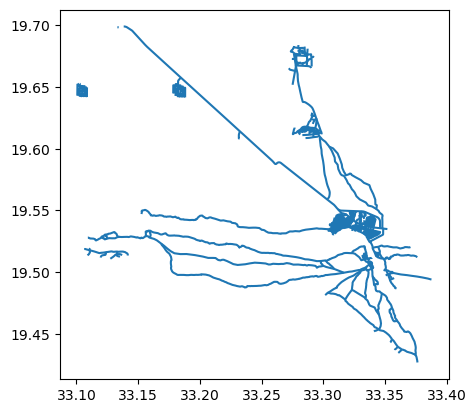

In [4]:
#load ci data using osm_flex
path_ctr_dump = download.get_country_geofabrik(iso3)

#load roads
road_network = road_prep_osm(reg_shape, path_ctr_dump=path_ctr_dump)

#plot
road_network.edges.plot()


Number of clusters in the network before merging: 587
2025-12-02 17:21:40,537 - climada_petals.engine.networks.nw_calcs - INFO - None
! adding distance
! adding distance
! adding distance
! adding distance
! adding distance
Number of clusters in the network after merging: 1
2025-12-02 17:21:44,816 - climada_petals.engine.networks.nw_calcs - INFO - None


<Axes: >

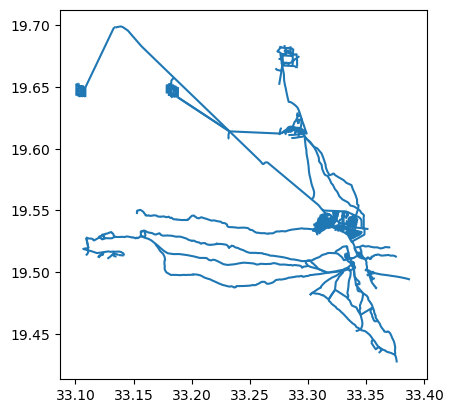

In [5]:
#link clusters
import numpy as np
from climada_petals.engine.networks.nw_calcs import NetworkCalcs
road_nw_calc = NetworkCalcs(road_network, dep_table=None)
road_nw_calc.merge_clusters(ci_type="road", max_iter=5, dist_thresh=np.inf)
road_network = road_nw_calc.network
road_network.edges.plot()


extract multipolygons: 100%|██████████| 310/310 [00:13<00:00, 22.34it/s]
endpoints: 0it [00:00, ?it/s]
topology: 0it [00:00, ?it/s]


<Axes: >

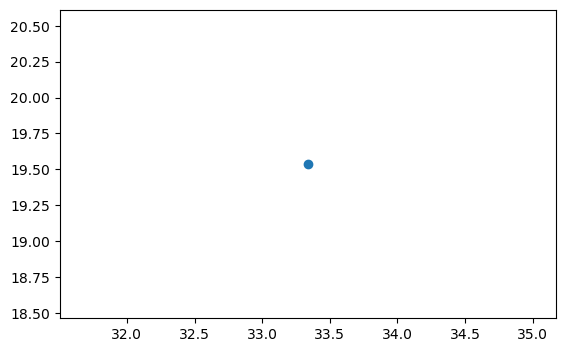

In [6]:
#load healthcare
healthcare_network = ci_prep_osm('healthcare', path_ctr_dump=path_ctr_dump, reg_shape=reg_shape)
healthcare_network.nodes.plot()

/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_utils.py:415: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cum = gdf_people.groupby(
endpoints: 0it [00:00, ?it/s]
/Users/lseverino/miniforge3/envs/nw_update/lib/python3.11/site-packages/geopandas/array.py:1755: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
topology: 0it [00:00, ?it/s]


<Axes: >

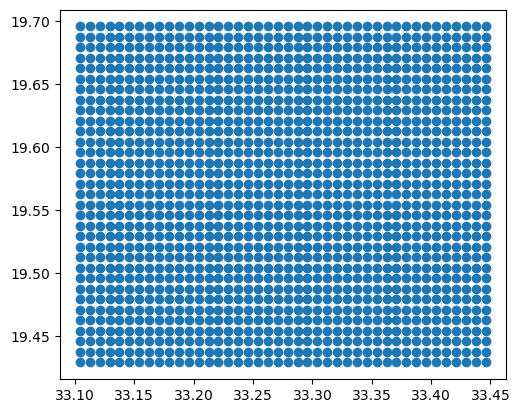

In [7]:
#load people
filename = f'{iso3.lower()}_ppp_2020_1km_Aggregated_UNadj.tif'
if not Path(PATH_SAVE / filename).is_file():
    nwu.get_worldpop_data(iso3, PATH_SAVE, res=1000)
people_network = pop_prep(iso3, reg_shape, filename, up_fct=1, ppl_ctf=0)
people_network.nodes.plot()

In [8]:
#combine
network_all = Network.from_nws([road_network, healthcare_network, people_network])

/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_base.py:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  edges = pd.concat([edges, edge_gdf])
/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_base.py:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  edges = pd.concat([edges, edge_gdf])


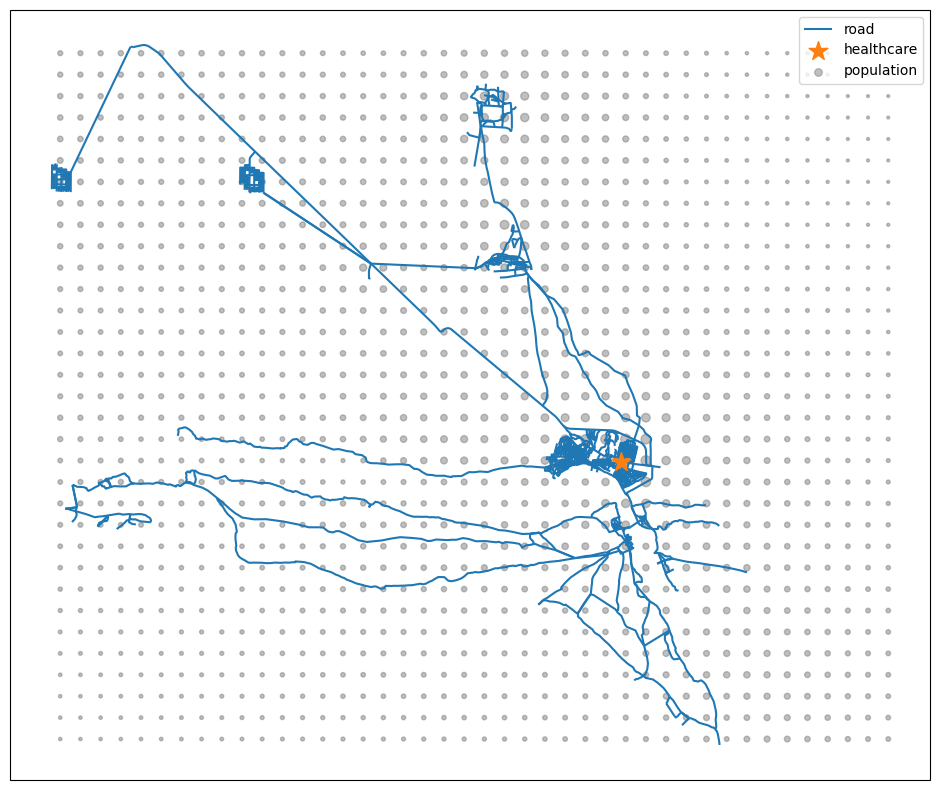

In [9]:
#reproject network for plotting
import cartopy.crs as ccrs
import copy as cp
import matplotlib.pyplot as plt
network_all_rp = cp.deepcopy(network_all)
network_all_rp.reproject('EPSG:3857')
projection = ccrs.Mercator()

fig, axes = plt.subplots(1, 1, subplot_kw=dict(projection=projection), figsize=(15,10))
fig, axes = network_all_rp.plot_infra(axes=axes, projection=projection, colors=["#1f77b4", "#ff7f0e",  "#bebebe"])


## Network and dependency set-up

In [10]:
import pandas as pd
import numpy as np
#set up dependency table
def make_dependency_table():
    cols = ['Dep', 'source', 'target', 'n_links', 'access_cnstr', 'type_I',
       'type_II', 'thresh_func', 'thresh_dist', 'thresh_dur', 'conditions',
       'link_condition', 'via_link', 'bidir_link']
    return pd.DataFrame(columns=cols)

df_dependencies = make_dependency_table()

#add dependencies
df_dependencies = pd.DataFrame([
    #people to healthcare
    {
    'Dep': 'dependency_healthcare_people',
    'source': 'healthcare',
    'target': 'people',
    'n_links': 1,
    'access_cnstr': True,
    'type_I': 'enduser',
    'type_II': 'logical',
    'thresh_func': 1,
    'thresh_dist': 50000,
    'thresh_dur': 90,
    'conditions': None,
    'link_condition': 'distance',
    'via_link': 'road',
    'bidir_link': True
    },
    {
    'Dep': 'dependency_road_healthcare',
    'source': 'road',
    'target': 'healthcare',
    'n_links': 10,
    'access_cnstr': True,
    'type_I': 'functional',
    'type_II': 'logical',
    'thresh_func': 1,
    'thresh_dist': np.inf,
    'thresh_dur': None,
    'conditions': None,
    'link_condition': 'edgecond',
    'via_link': None,
    'bidir_link': True
    },
    {
    'Dep': 'dependency_road_people',
    'source': 'road',
    'target': 'people',
    'n_links': 1,
    'access_cnstr': True,
    'type_I': 'enduser',
    'type_II': 'logical',
    'thresh_func': 1,
    'thresh_dist': 1000,
    'thresh_dur': 60,
    'conditions': None,
    'link_condition': 'distance',
    'via_link': 'road',
    'bidir_link': True
    }])
df_dependencies


,Dep,source,target,n_links,access_cnstr,type_I,type_II,thresh_func,thresh_dist,thresh_dur,conditions,link_condition,via_link,bidir_link
0,dependency_healthcare_people,healthcare,people,1,True,enduser,logical,1,50000.0,90.0,None,distance,road,True
1,dependency_road_healthcare,road,healthcare,10,True,functional,logical,1,inf,NaN,None,edgecond,None,True
2,dependency_road_people,road,people,1,True,enduser,logical,1,1000.0,60.0,None,distance,road,True


In [11]:
from climada_petals.engine.networks.nw_calcs import NetworkCalcs

#create network calculator with dependency table
nw_calc_test = NetworkCalcs(network_all, dep_table=df_dependencies)

#add missing physical links
nw_calc_test.add_physical_links()

#initialize base state
nw_calc_test.initialize_base_state()

#setup dependencies
nw_calc_test.setup_dependencies()

#run cascade for base access state
nw_calc_test.cascade(criterion="distance", initial=True)

! adding distance
! adding distance
! adding distance
2025-12-02 17:22:16,713 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: -1
2025-12-02 17:22:16,723 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-12-02 17:22:16,724 - climada_petals.engine.networks.nw_calcs - WARNING - Road access condition for CI-CI deps not yet implemented
2025-12-02 17:22:16,813 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: 10
2025-12-02 17:22:16,814 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-12-02 17:22:16,815 - climada_petals.engine.networks.nw_calcs - WARNING - Road access condition for CI-CI deps not yet implemented
2025-12-02 17:22:16,892 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: 1
2025-12-02 17:22:16,892 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-12-02 17:22:16,893 - climada_petals.eng

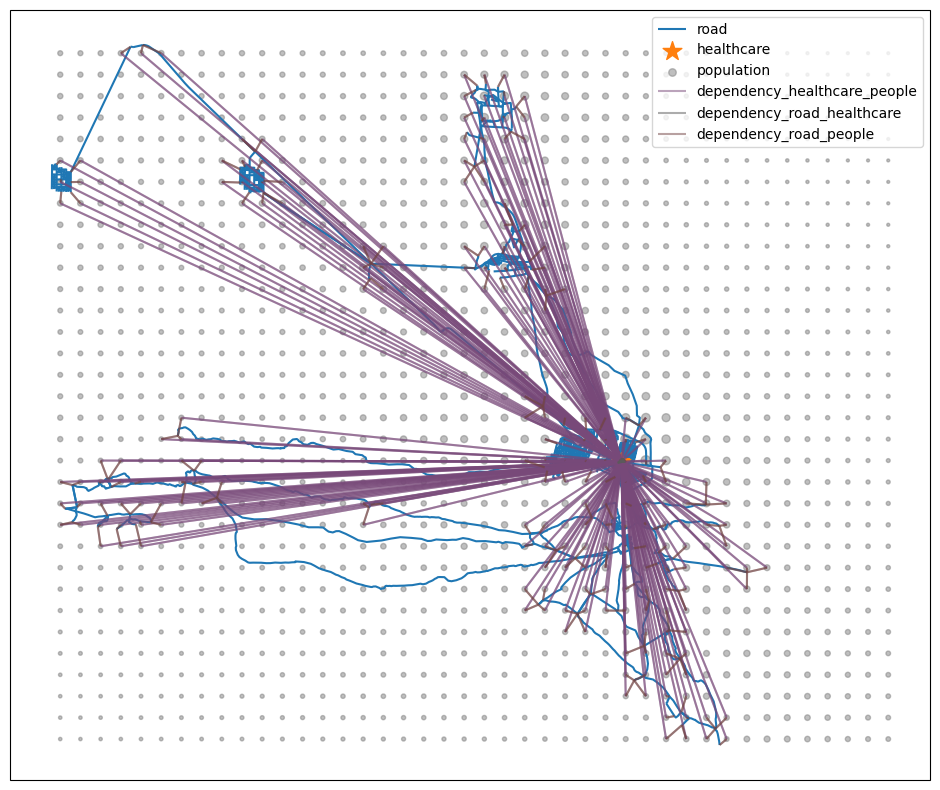

In [13]:
#fig, axes = plt.subplots(1, 1, subplot_kw=dict(projection=projection))
dep_network = cp.deepcopy(nw_calc_test.network)
dep_network.reproject('EPSG:3857')
projection = ccrs.Mercator()
fig, axes = dep_network.plot_dep(axes=axes, projection=projection,colors=["#784979", "#5b5b5b", "#724444"])
fig

## Network impact calculation

In [14]:
#load hazard
from climada.hazard.base import Hazard
from climada.util.api_client import Client

client = Client()
rf_dataset_infos = client.list_dataset_infos(data_type="river_flood")


2025-12-02 17:23:16,405 - climada.hazard.io - INFO - Reading /Users/lseverino/climada/data/hazard/river_flood/river_flood_150arcsec_hist_SDN_1980_2000/v2/river_flood_150arcsec_hist_SDN_1980_2000.hdf5


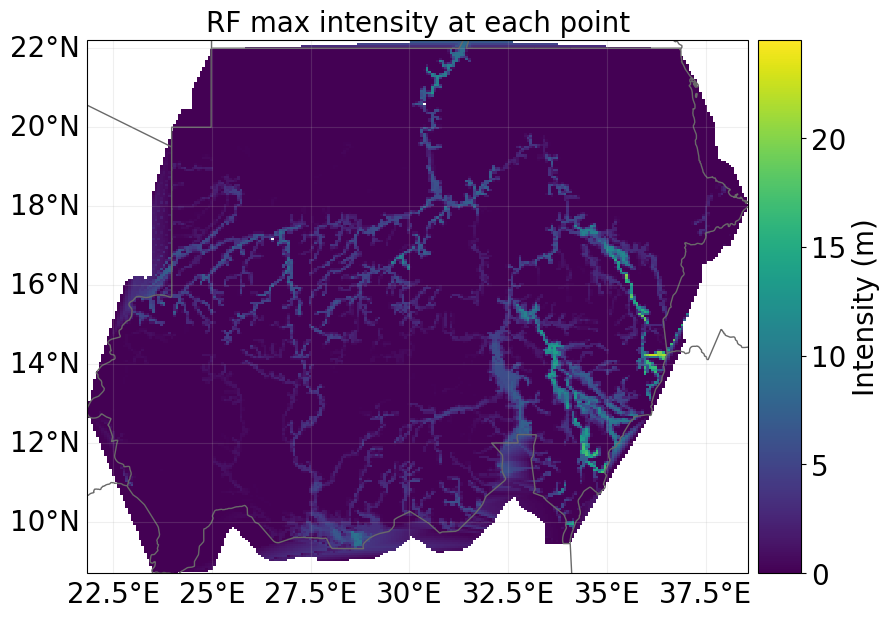

In [15]:
client = Client()
rf_sudan = client.get_hazard(
    "river_flood",
    properties={
        "country_name": "Sudan",
        "climate_scenario": "historical",
        "year_range" : "1980_2000"
    },
)
rf_sudan.plot_intensity(0);

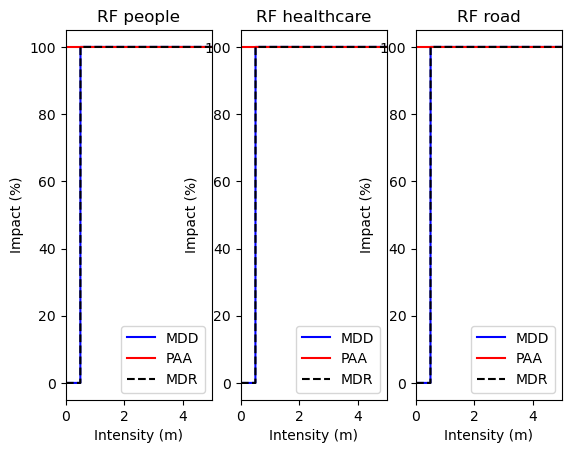

In [16]:
#prepare impact functions
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

#make impact functions
def make_step_impf(thresh, haz_type, ci_type):
        step_impf = ImpactFunc()
        step_impf.id = ci_type
        step_impf.haz_type = haz_type
        step_impf.name = ci_type
        step_impf.intensity_unit = 'm'
        step_impf.intensity = np.array([0, 0.99*thresh, thresh, 2*thresh, 10*thresh])
        step_impf.mdd =       np.array([0, 0, 1, 1,1])
        step_impf.paa =       np.sort(np.linspace(1, 1, num=5))
        step_impf.check()
        return step_impf


impf_set = ImpactFuncSet()
impf_set.append(make_step_impf(0.5, rf_sudan.haz_type, "people"))
impf_set.append(make_step_impf(0.5, rf_sudan.haz_type, "healthcare"))
impf_set.append(make_step_impf(0.5, rf_sudan.haz_type, "road"))
impf_set.plot()

#store functionality thresholds in dict
thresh_func_dict = {"people" : 0.5, "healthcare" : 0.5, "road" : 0.5}

In [17]:
from climada_petals.engine.networks.nw_impacts import exposure_from_edges, exposure_from_nodes
from climada_petals.engine.networks.nw_impacts import NetworkImpactCalc
import copy as cp

#prepare exposures from base network
network_base = cp.deepcopy(nw_calc_test.network)
exp_ppl = exposure_from_nodes(network_base, ci_type="people", value_col="counts")
exp_hc = exposure_from_nodes(network_base, ci_type="healthcare", value=1)
exp_rd = exposure_from_edges(network_base, ci_type="road", res=500)
exp_list = [exp_ppl, exp_hc, exp_rd]


#select hazard, impf
haz = rf_sudan.select(event_id=[1])
impf_set = impf_set
impf_thresh_set = thresh_func_dict

#create nw_impact_object
nw_impact_calc = NetworkImpactCalc(network=network_base, impf_set=impf_set,
                                   impf_thresh_set=impf_thresh_set, haz=haz, exp_list=exp_list)

#run impact calculation
network_disrupted, impact_dict = nw_impact_calc.disrupt_network()

2025-12-02 17:23:22,361 - climada.entity.exposures.base - INFO - Setting latitude and longitude attributes.
2025-12-02 17:23:22,370 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2025-12-02 17:23:22,371 - climada.entity.exposures.base - INFO - category_id not set.
2025-12-02 17:23:22,372 - climada.entity.exposures.base - INFO - cover not set.
2025-12-02 17:23:22,372 - climada.entity.exposures.base - INFO - deductible not set.
2025-12-02 17:23:22,372 - climada.entity.exposures.base - INFO - region_id not set.
2025-12-02 17:23:22,373 - climada.entity.exposures.base - INFO - centr_ not set.
2025-12-02 17:23:22,374 - climada.entity.exposures.base - INFO - Setting latitude and longitude attributes.
2025-12-02 17:23:22,375 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2025-12-02 17:23:22,375 - climada.entity.exposures.base - INFO - category_id not set.
2025-12-02 17:23:22,375 - climada.

/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_impacts.py:150: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gdf_nodes_or_edges.loc[gdf_nodes_or_edges.ci_type==exp_tag,


<GeoAxes: title={'center': 'Expected annual impact'}>

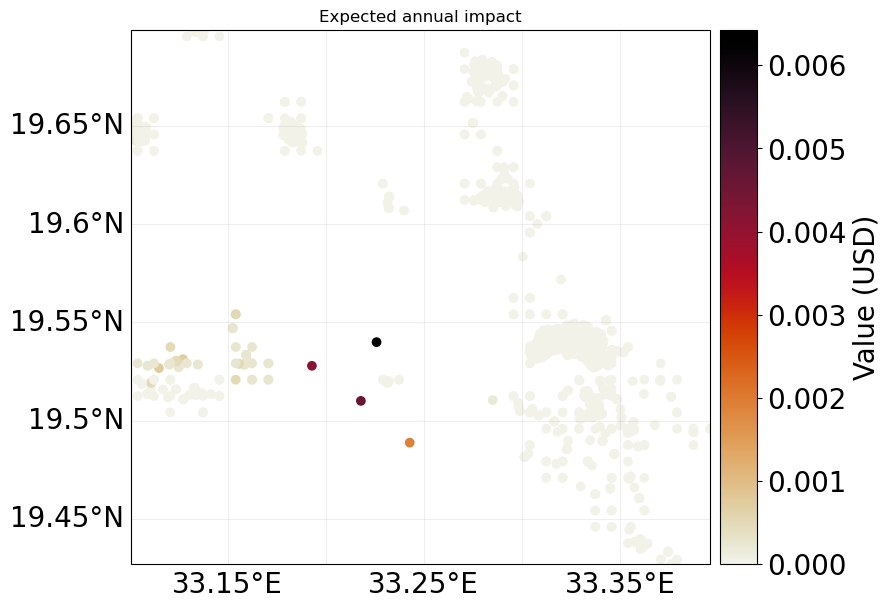

In [18]:
impact_dict["road"].plot_scatter_eai_exposure()

In [19]:
#re run cascade to get indirect cascading impacts
nw_calc_disrupted = NetworkCalcs(network_disrupted, dep_table=df_dependencies)
nw_calc_disrupted.cascade(criterion="distance", initial=False)


2025-12-02 17:23:22,999 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: -1
2025-12-02 17:23:23,011 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-12-02 17:23:23,012 - climada_petals.engine.networks.nw_calcs - WARNING - Road access condition for CI-CI deps not yet implemented
2025-12-02 17:23:23,109 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: 22
2025-12-02 17:23:23,109 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-12-02 17:23:23,110 - climada_petals.engine.networks.nw_calcs - WARNING - Road access condition for CI-CI deps not yet implemented
2025-12-02 17:23:23,202 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: 1
2025-12-02 17:23:23,203 - climada_petals.engine.networks.nw_calcs - INFO - Updating roads
2025-12-02 17:23:23,204 - climada_petals.engine.networks.nw_calcs - WARNING - Road access conditio

<Axes: >

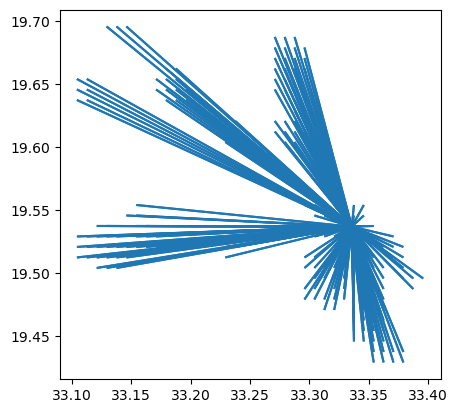

In [20]:
nw_calc_disrupted.network.edges[nw_calc_disrupted.network.edges.ci_type=="dependency_healthcare_people"].plot()